<a href="https://colab.research.google.com/github/kelawady/Acoustic_Emissions/blob/main/AE_precursor_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AE precursor analysis sandbox

This notebook is a follow-on to the two earlier Colabs. It assumes the same Drive folder layout and the same saved artifacts:

- `event_signals_8K_25K_44K_combined.pkl`
- `P36_10um_Test1_synced_clean.csv`

The goal here is to try a few **simple, interpretable precursor analyses** before building heavier predictive models:

1. Build an event-level feature table.
2. Define **large events** by AE energy quantile.
3. Compare **near vs far** windows before large events.
4. Make **precursor-aligned trajectories** before large events.
5. Test simple **inter-event time shortening / rate acceleration**.
6. Optionally recompute the **4 archetypes** and inspect archetype fractions before large events.


## 1) Mount Drive and move into the project folder

Update `FOLDERNAME` only if your Drive path changed.


In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = 'EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# Change directory to current path
%cd /content/drive/My\ Drive/$FOLDERNAME/
!pwd
!ls

Mounted at /content/drive
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
 AE_detection_results
 before_after_2bpf.png
 before_after_8KhzNpotch.png
 before_after_hpf.png
 event_signals_8K_25K_44K_combined.pkl
 event_signals_8K_25K_44K.pkl
 hw1_prob2a.png
 non_event_signals_8K_25K_44K_combined.pkl
 P36_10um_Test1_synced_clean.csv
 P36_10um_Test1_synced.csv
 P36_filt_20k_60K_segments
 P36_filt_2K_60K.npy
 P36_filt_2k_60K_segments
 P36_filtered_waveform_30-50_kHz.wav
 P36_filtered_waveform_32-46_kHz.wav
 P36_raw_segments
 P36_raw_waveform.wav
'Pillar 36_10um.DTA'
'Pillar 36_10um_Waveform20240721-194953-051.wfs'
 raw_signal_histogram.png
 raw_signal.png
 raw_signal_segments.png
 raw_signal_spectrogram.png


## 2) Imports and load the saved event / mechanical data


In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import hilbert
from scipy.stats import kurtosis
from scipy.ndimage import gaussian_filter1d

FS_AE = 2_000_000.0  # Hz

with open('event_signals_8K_25K_44K_combined.pkl', 'rb') as f:
    combined_events = pickle.load(f)

csv_path = 'P36_10um_Test1_synced_clean.csv'
df_mech = pd.read_csv(csv_path)

strain_time = df_mech['Time (s)'].to_numpy(dtype=float)
strain = df_mech['Strain (%)'].to_numpy(dtype=float)
stress = df_mech['Stress (Mpa)'].to_numpy(dtype=float)

print('Combined events:', len(combined_events))
print('Mechanical samples:', len(strain_time))
print('Mechanical time span (s):', float(np.nanmin(strain_time)), 'to', float(np.nanmax(strain_time)))


Combined events: 266
Mechanical samples: 80672
Mechanical time span (s): -1.039913 to 132.0622604


## 3) Build an event-level feature table

This recreates a compact per-event DataFrame so we can do time-resolved and precursor analyses easily.


In [3]:
def _rms(x, eps=1e-12):
    return float(np.sqrt(np.mean(x * x))) + eps

def _normalize_rms(x):
    return x / _rms(x)

def _zcr_per_sample(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def _spec_features_abs_freq(x, fs_hz):
    X = np.fft.rfft(x)
    mag = np.abs(X)
    if mag.size == 0:
        return np.nan, np.nan, np.nan
    mag[0] = 0.0
    f_hz = np.fft.rfftfreq(len(x), d=1.0 / fs_hz)
    mag_sum = float(np.sum(mag)) + 1e-12
    p = mag / mag_sum
    centroid_hz = float(np.sum(f_hz * mag) / mag_sum)
    bandwidth_hz = float(np.sqrt(np.sum(((f_hz - centroid_hz) ** 2) * mag) / mag_sum))
    entropy = float(-np.sum(p * np.log(p + 1e-12)))
    return centroid_hz, bandwidth_hz, entropy

def _envelope_rise_decay_fracs(x):
    env = np.abs(hilbert(x))
    N = len(env)
    pk = int(np.argmax(env))
    rise = float(pk / max(N - 1, 1))
    pk_env = float(env[pk])
    target = pk_env / np.e
    after = env[pk:]
    below = np.where(after <= target)[0]
    dec_idx = pk + int(below[0]) if below.size > 0 else N - 1
    decay = float((dec_idx - pk) / max(N - 1, 1))
    return rise, decay

def build_event_df(combined_events, fs_hz=FS_AE):
    records = []
    events_sorted = sorted(combined_events.values(), key=lambda e: e.get('global_start_time_s', 0.0))

    for idx, ev in enumerate(events_sorted):
        x = np.asarray(ev.get('signal', []), dtype=float)
        x = x[np.isfinite(x)]
        if x.size < 16:
            continue

        onset = float(ev.get('global_start_time_s', np.nan))
        duration_s = float(ev.get('duration_s', x.size / fs_hz))
        end_time = onset + duration_s
        energy = float(np.sum(x ** 2))
        rms = float(np.sqrt(np.mean(x ** 2)))
        peak_abs = float(np.max(np.abs(x)))

        xn = _normalize_rms(x)
        rise_frac, decay_frac = _envelope_rise_decay_fracs(xn)
        zcr = _zcr_per_sample(xn)
        centroid_hz, bandwidth_hz, spec_entropy = _spec_features_abs_freq(xn, fs_hz)

        records.append({
            'event_idx': idx,
            'onset_s': onset,
            'end_s': end_time,
            'duration_s': duration_s,
            'duration_us': duration_s * 1e6,
            'n_samples': int(x.size),
            'energy': energy,
            'log10_energy': np.log10(energy + 1e-12),
            'rms': rms,
            'peak_abs': peak_abs,
            'kurtosis': float(kurtosis(xn, fisher=False, bias=False)),
            'zcr_cross_per_sample': zcr,
            'zcr_hz': zcr * fs_hz,
            'rise_frac': rise_frac,
            'decay_frac': decay_frac,
            'spec_centroid_khz': centroid_hz / 1e3,
            'spec_bandwidth_khz': bandwidth_hz / 1e3,
            'spec_entropy': spec_entropy,
        })

    evdf = pd.DataFrame.from_records(records).sort_values('onset_s').reset_index(drop=True)
    evdf['inter_event_time_s'] = evdf['onset_s'].diff()
    evdf['cum_energy'] = evdf['energy'].cumsum()
    return evdf

evdf = build_event_df(combined_events)
evdf.head()


,event_idx,onset_s,end_s,duration_s,duration_us,n_samples,energy,log10_energy,rms,peak_abs,kurtosis,zcr_cross_per_sample,zcr_hz,rise_frac,decay_frac,spec_centroid_khz,spec_bandwidth_khz,spec_entropy,inter_event_time_s,cum_energy
0,0,3.248461,3.248570,0.000109,109.0,218,0.634112,-0.197834,0.053933,0.088087,1.622647,0.023041,46082.949309,0.230415,0.769585,148.029940,228.208326,3.211737,NaN,0.634112
1,1,3.764925,3.765041,0.000116,116.0,232,0.751662,-0.123978,0.056920,0.117519,2.025627,0.021645,43290.043290,0.000000,0.878788,175.319350,246.160854,3.627705,0.516465,1.385774
2,2,3.916612,3.916724,0.000112,112.0,224,0.827483,-0.082241,0.060779,0.118941,1.980728,0.022422,44843.049327,1.000000,0.000000,158.530149,238.018551,3.379352,0.151687,2.213256
3,3,7.289121,7.289226,0.000106,105.5,211,0.627463,-0.202412,0.054532,0.122237,2.133382,0.023810,47619.047619,0.190476,0.771429,148.688632,231.251190,3.125928,3.372508,2.840719
4,4,10.078684,10.078808,0.000124,124.5,249,0.560461,-0.251454,0.047443,0.080036,1.750966,0.024194,48387.096774,0.762097,0.237903,96.938260,181.373644,2.812269,2.789563,3.401181


Event feature table shape: (266, 20)
          onset_s  duration_us      energy  spec_centroid_khz  spec_entropy
count  266.000000   266.000000  266.000000         266.000000    266.000000
mean    81.255607   202.582707    5.847311          82.136177      2.859706
std     27.787526   220.370277   15.226963          39.873739      0.571108
min      3.248461   100.000000    0.416418          27.507701      1.648771
25%     68.416758   107.000000    0.883887          51.417671      2.412733
50%     84.044844   126.750000    1.885238          70.197600      2.837706
75%     99.716090   197.875000    4.138148         111.248806      3.240284
max    135.934765  1540.500000  123.296775         193.257226      4.748966


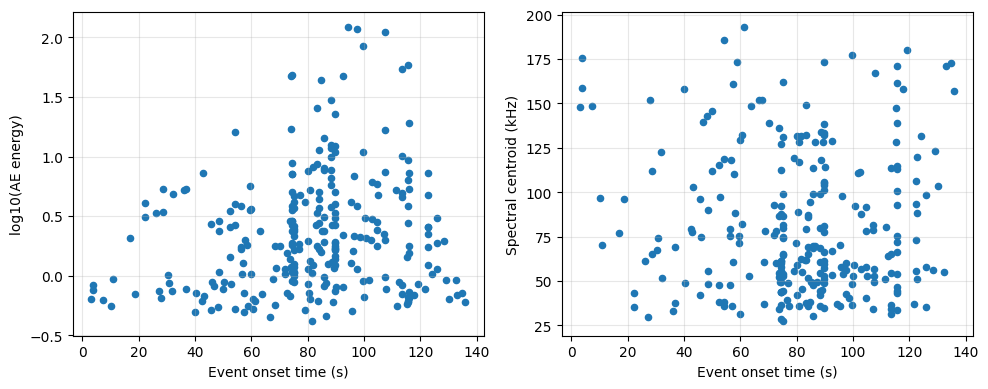

In [5]:
print('Event feature table shape:', evdf.shape)
print(evdf[['onset_s','duration_us','energy','spec_centroid_khz','spec_entropy']].describe())

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(evdf['onset_s'], evdf['log10_energy'], s=20)
plt.xlabel('Event onset time (s)')
plt.ylabel('log10(AE energy)')
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(evdf['onset_s'], evdf['spec_centroid_khz'], s=20)
plt.xlabel('Event onset time (s)')
plt.ylabel('Spectral centroid (kHz)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4) Define what counts as a “large event”

Start simple: define large events as the top `LARGE_Q` quantile of AE energy. You can change this to 0.85, 0.90, 0.95, etc.


Large-event energy threshold (q=0.90): 9.154
Large events: 27 out of 266


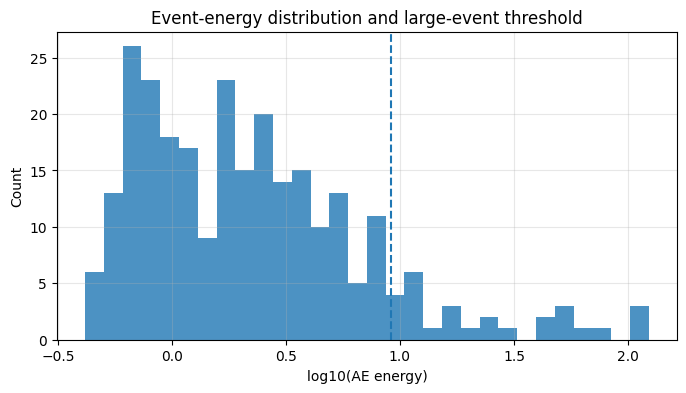

In [6]:
LARGE_Q = 0.90
energy_thresh = evdf['energy'].quantile(LARGE_Q)
evdf['is_large'] = evdf['energy'] >= energy_thresh

print(f'Large-event energy threshold (q={LARGE_Q:.2f}): {energy_thresh:.4g}')
print('Large events:', int(evdf['is_large'].sum()), 'out of', len(evdf))

plt.figure(figsize=(8,4))
plt.hist(evdf['log10_energy'], bins=30, alpha=0.8)
plt.axvline(np.log10(energy_thresh), linestyle='--')
plt.xlabel('log10(AE energy)')
plt.ylabel('Count')
plt.title('Event-energy distribution and large-event threshold')
plt.grid(True, alpha=0.3)
plt.show()


## 5) Near-vs-far window comparison before large events

This is the quickest precursor test: compare windows very close to large events with windows farther away before those same events.

By default below, we compare:
- **near window:** 0 to 1 s before each large event
- **far window:** 5 to 10 s before each large event


In [7]:
NEAR_WIN = (0.0, 1.0)   # seconds before large event
FAR_WIN  = (5.0, 10.0)  # seconds before large event

FEATURES_TO_COMPARE = [
    'energy',
    'duration_us',
    'spec_centroid_khz',
    'spec_entropy',
    'zcr_hz',
]

def collect_window_events(evdf, target_times, win):
    lo, hi = win
    chunks = []
    for t0 in target_times:
        m = (evdf['onset_s'] >= (t0 - hi)) & (evdf['onset_s'] < (t0 - lo))
        chunk = evdf.loc[m].copy()
        if len(chunk):
            chunk['target_large_time_s'] = t0
            chunk['time_before_target_s'] = t0 - chunk['onset_s']
            chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=evdf.columns)

large_times = evdf.loc[evdf['is_large'], 'onset_s'].to_numpy(dtype=float)
near_df = collect_window_events(evdf, large_times, NEAR_WIN)
far_df  = collect_window_events(evdf, large_times, FAR_WIN)

summary_rows = []
for feat in FEATURES_TO_COMPARE:
    near_med = float(np.nanmedian(near_df[feat])) if len(near_df) else np.nan
    far_med  = float(np.nanmedian(far_df[feat])) if len(far_df) else np.nan
    ratio = near_med / far_med if np.isfinite(near_med) and np.isfinite(far_med) and abs(far_med) > 1e-12 else np.nan
    summary_rows.append({
        'feature': feat,
        'near_median': near_med,
        'far_median': far_med,
        'near/far': ratio,
    })

summary_df = pd.DataFrame(summary_rows)
print('Near-window events:', len(near_df))
print('Far-window events:', len(far_df))
display(summary_df)


Near-window events: 135
Far-window events: 415


,feature,near_median,far_median,near/far
0,energy,2.759797,2.100826,1.313672
1,duration_us,147.000000,136.000000,1.080882
2,spec_centroid_khz,69.565409,62.233174,1.117819
3,spec_entropy,2.940850,2.825445,1.040845
4,zcr_hz,61744.966443,63926.940639,0.965868


/tmp/ipykernel_159/1377507389.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, labels=labels, showfliers=False)
/tmp/ipykernel_159/1377507389.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, labels=labels, showfliers=False)
/tmp/ipykernel_159/1377507389.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, labels=labels, showfliers=False)
/tmp/ipykernel_159/1377507389.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, l

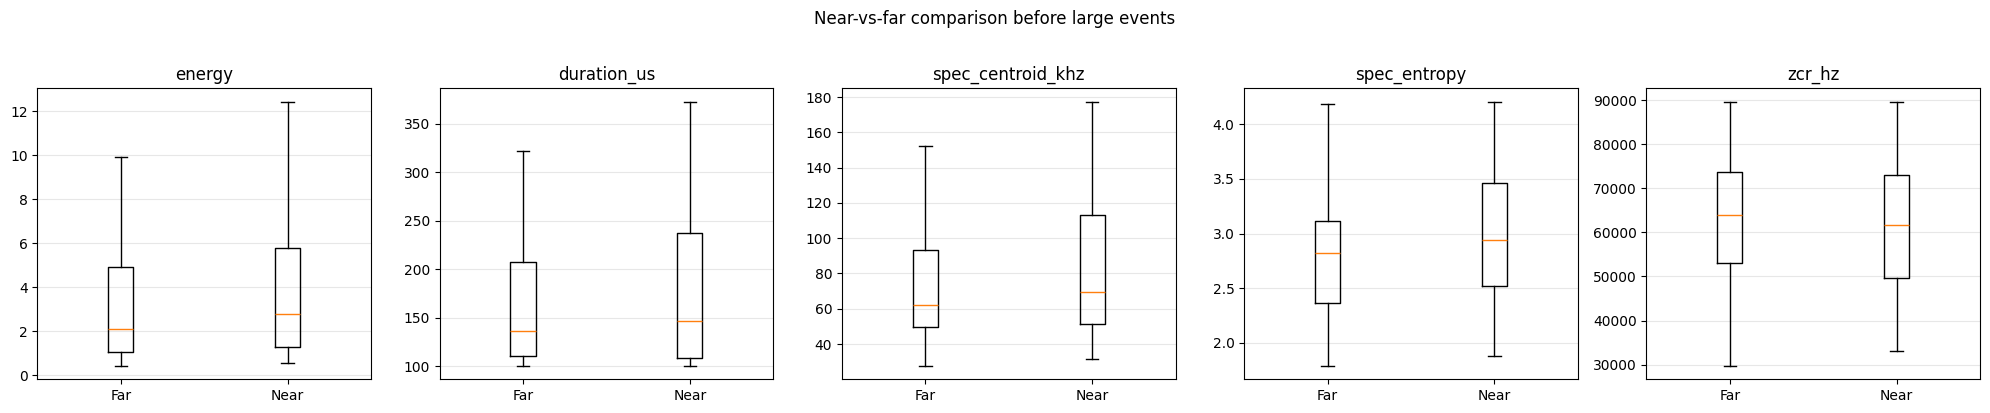

In [8]:
fig, axes = plt.subplots(1, len(FEATURES_TO_COMPARE), figsize=(4*len(FEATURES_TO_COMPARE), 4), sharey=False)
if len(FEATURES_TO_COMPARE) == 1:
    axes = [axes]

for ax, feat in zip(axes, FEATURES_TO_COMPARE):
    vals = []
    labels = []
    if len(far_df):
        vals.append(far_df[feat].dropna().to_numpy())
        labels.append('Far')
    if len(near_df):
        vals.append(near_df[feat].dropna().to_numpy())
        labels.append('Near')
    ax.boxplot(vals, labels=labels, showfliers=False)
    ax.set_title(feat)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Near-vs-far comparison before large events', y=1.02)
plt.tight_layout()
plt.show()


## 6) Precursor-aligned trajectories before large events

This aligns many large events at time 0 and averages the event statistics seen beforehand. This is often the most revealing “simple” precursor plot.


In [9]:
PRECURSOR_HORIZON_S = 10.0
DT_BIN_S = 0.5
MIN_EVENTS_PER_BIN = 3

METRICS = ['event_rate_hz', 'mean_log10_energy', 'median_centroid_khz', 'median_entropy', 'median_duration_us']

def build_precursor_grid(evdf, target_times, horizon_s=10.0, dt_bin_s=0.5):
    edges = np.arange(0.0, horizon_s + dt_bin_s, dt_bin_s)
    centers = 0.5 * (edges[:-1] + edges[1:])

    rows = []
    for c in centers:
        lo = c - dt_bin_s/2
        hi = c + dt_bin_s/2
        per_target = []
        for t0 in target_times:
            m = (evdf['onset_s'] >= (t0 - hi)) & (evdf['onset_s'] < (t0 - lo))
            chunk = evdf.loc[m]
            per_target.append({
                'count': len(chunk),
                'event_rate_hz': len(chunk) / dt_bin_s,
                'mean_log10_energy': chunk['log10_energy'].mean() if len(chunk) else np.nan,
                'median_centroid_khz': chunk['spec_centroid_khz'].median() if len(chunk) else np.nan,
                'median_entropy': chunk['spec_entropy'].median() if len(chunk) else np.nan,
                'median_duration_us': chunk['duration_us'].median() if len(chunk) else np.nan,
            })
        tmp = pd.DataFrame(per_target)
        rows.append({
            'time_before_s': c,
            'n_targets_with_any_events': int((tmp['count'] > 0).sum()),
            'event_rate_hz': tmp['event_rate_hz'].mean(),
            'mean_log10_energy': tmp['mean_log10_energy'].mean(),
            'median_centroid_khz': tmp['median_centroid_khz'].mean(),
            'median_entropy': tmp['median_entropy'].mean(),
            'median_duration_us': tmp['median_duration_us'].mean(),
        })
    return pd.DataFrame(rows)

precursor_df = build_precursor_grid(evdf, large_times, horizon_s=PRECURSOR_HORIZON_S, dt_bin_s=DT_BIN_S)
precursor_df.head()


,time_before_s,n_targets_with_any_events,event_rate_hz,mean_log10_energy,median_centroid_khz,median_entropy,median_duration_us
0,0.25,24,7.333333,0.459938,81.098735,2.907743,172.500000
1,0.75,14,2.666667,0.263265,88.925816,2.821311,133.142857
2,1.25,12,2.222222,0.271486,65.524921,2.588254,139.375000
3,1.75,16,3.407407,0.178890,74.671443,2.683613,135.453125
4,2.25,20,5.407407,0.447505,61.214280,2.709413,180.137500


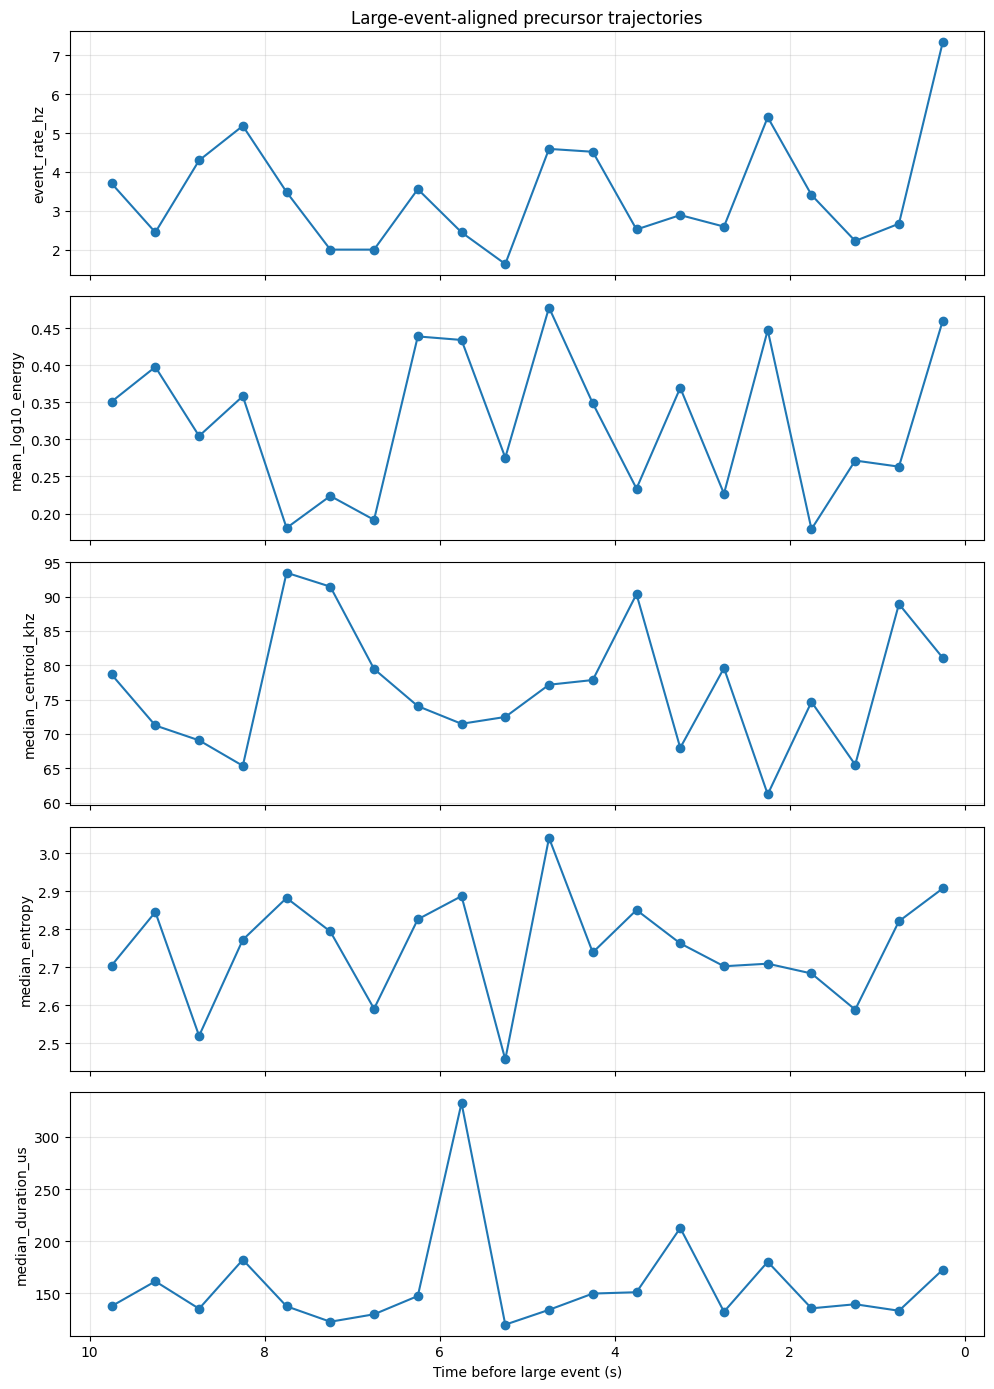

In [10]:
fig, axes = plt.subplots(len(METRICS), 1, figsize=(10, 2.8*len(METRICS)), sharex=True)
for ax, metric in zip(axes, METRICS):
    x = precursor_df['time_before_s']
    y = precursor_df[metric]
    ax.plot(x, y, marker='o')
    ax.invert_xaxis()  # time flows toward the large event
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Large-event-aligned precursor trajectories')
axes[-1].set_xlabel('Time before large event (s)')
plt.tight_layout()
plt.show()


## 7) Event-rate and inter-event-time shortening over the full experiment

Another easy precursor check is whether events become more frequent or more clustered before major activity.


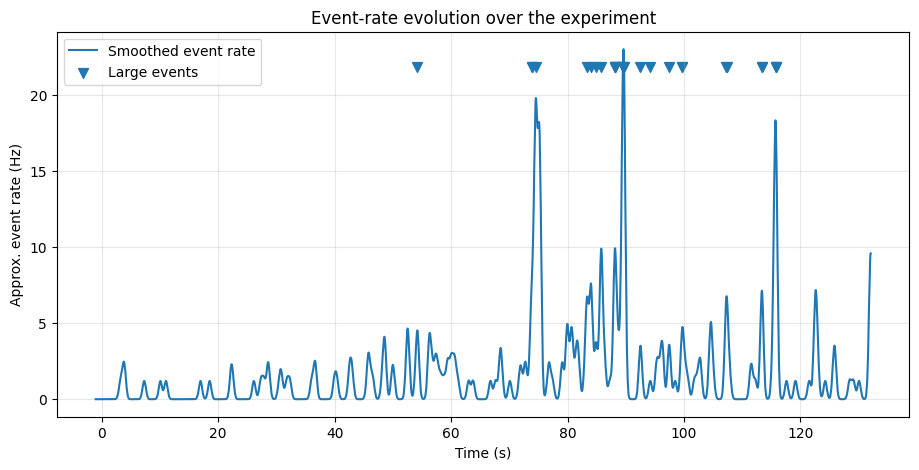

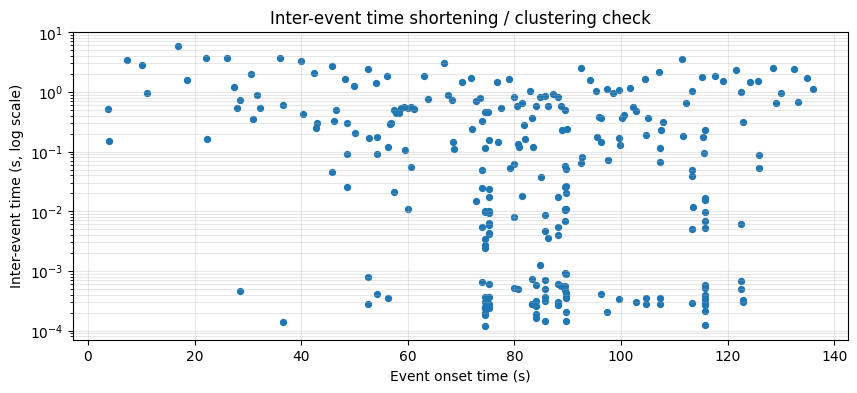

In [11]:
ROLLING_WIN_S = 2.0

# build a simple rate series on the mechanical time base
mech_t = np.asarray(strain_time, dtype=float)
mech_t = mech_t[np.isfinite(mech_t)]
mech_t = np.sort(mech_t)
dt_mech = float(np.median(np.diff(mech_t)))
rate_samples = max(3, int(round(ROLLING_WIN_S / dt_mech)))

spike_train = np.zeros_like(mech_t, dtype=float)
for t0 in evdf['onset_s'].to_numpy(dtype=float):
    idx = int(np.argmin(np.abs(mech_t - t0)))
    spike_train[idx] += 1.0

rolling_rate_hz = gaussian_filter1d(spike_train, sigma=max(1, rate_samples/6.0)) / dt_mech

plt.figure(figsize=(11,5))
plt.plot(mech_t, rolling_rate_hz, label='Smoothed event rate')
plt.scatter(evdf.loc[evdf['is_large'], 'onset_s'], np.full(evdf['is_large'].sum(), np.nanmax(rolling_rate_hz)*0.95),
            marker='v', s=50, label='Large events')
plt.xlabel('Time (s)')
plt.ylabel('Approx. event rate (Hz)')
plt.title('Event-rate evolution over the experiment')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.scatter(evdf['onset_s'], evdf['inter_event_time_s'], s=18)
plt.yscale('log')
plt.xlabel('Event onset time (s)')
plt.ylabel('Inter-event time (s, log scale)')
plt.title('Inter-event time shortening / clustering check')
plt.grid(True, which='both', alpha=0.3)
plt.show()


## 8) A simple lead-up analysis for the single largest events

This plots trajectories leading into the top `TOP_N_TARGETS` largest events, one trace per target, plus the average.


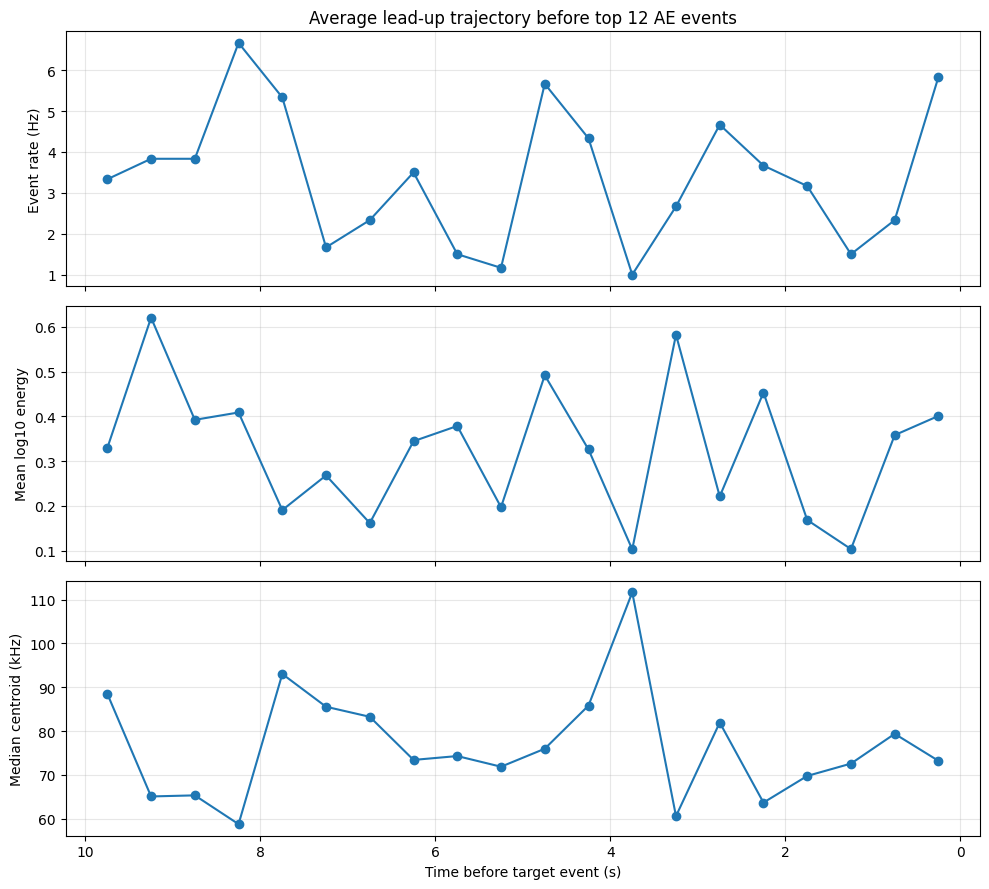

In [12]:
TOP_N_TARGETS = 12
HORIZON_S = 10.0

largest_targets = evdf.nlargest(TOP_N_TARGETS, 'energy')['onset_s'].to_numpy(dtype=float)
lead_df = build_precursor_grid(evdf, largest_targets, horizon_s=HORIZON_S, dt_bin_s=DT_BIN_S)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, metric, ylabel in [
    (axes[0], 'event_rate_hz', 'Event rate (Hz)'),
    (axes[1], 'mean_log10_energy', 'Mean log10 energy'),
    (axes[2], 'median_centroid_khz', 'Median centroid (kHz)'),
]:
    ax.plot(lead_df['time_before_s'], lead_df[metric], marker='o')
    ax.invert_xaxis()
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'Average lead-up trajectory before top {TOP_N_TARGETS} AE events')
axes[-1].set_xlabel('Time before target event (s)')
plt.tight_layout()
plt.show()


## 9) Optional: recompute the 4 event archetypes and inspect archetype fractions before large events

This mirrors the earlier clustering logic closely enough to be useful for precursor analysis. If you want to skip it, you can skip the next three cells.


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

try:
    import pywt
    HAS_PYWT = True
except Exception:
    HAS_PYWT = False
    print('PyWavelets not available; wavelet features will be skipped.')

def _wavelet_fractions_entropy(x, wavelet='db4', level=3):
    if not HAS_PYWT:
        return None
    coeffs = pywt.wavedec(x, wavelet, level=level)
    A3, D3, D2, D1 = coeffs[0], coeffs[1], coeffs[2], coeffs[3]
    EA3 = float(np.sum(np.asarray(A3) ** 2))
    ED3 = float(np.sum(np.asarray(D3) ** 2))
    ED2 = float(np.sum(np.asarray(D2) ** 2))
    ED1 = float(np.sum(np.asarray(D1) ** 2))
    Etot = EA3 + ED3 + ED2 + ED1 + 1e-12
    frD1, frD2, frD3, frA3 = ED1/Etot, ED2/Etot, ED3/Etot, EA3/Etot
    p = np.array([frD1, frD2, frD3, frA3], dtype=float)
    went = float(-np.sum(p * np.log(p + 1e-12)))
    return [frD1, frD2, frD3, frA3, went, frD1]

def extract_mechanism_feature_matrix(combined_events, fs_hz=FS_AE):
    rows = []
    kept_indices = []
    events_sorted = sorted(combined_events.values(), key=lambda e: e.get('global_start_time_s', 0.0))
    for idx, ev in enumerate(events_sorted):
        x = np.asarray(ev.get('signal', []), dtype=float)
        x = x[np.isfinite(x)]
        if x.size < 32:
            continue
        duration_s = float(ev.get('duration_s', x.size / fs_hz))
        xn = _normalize_rms(x)
        rise, decay = _envelope_rise_decay_fracs(xn)
        zps = _zcr_per_sample(xn)
        cent_hz, bw_hz, sent = _spec_features_abs_freq(xn, fs_hz)
        feats = [
            np.log10(duration_s + 1e-12),
            rise,
            decay,
            float(kurtosis(xn, fisher=False, bias=False)),
            zps * fs_hz,
            cent_hz / 1e3,
            bw_hz / 1e3,
            sent,
        ]
        w = _wavelet_fractions_entropy(xn, wavelet='db4', level=3)
        if w is not None:
            feats.extend(w)
        rows.append(feats)
        kept_indices.append(idx)
    return np.asarray(rows, dtype=float), np.asarray(kept_indices, dtype=int)

X_event, kept_idx = extract_mechanism_feature_matrix(combined_events)
Xz = StandardScaler().fit_transform(X_event)
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=0, n_init=10)
labels = gmm.fit_predict(Xz)

# map back to evdf rows
cluster_label = np.full(len(evdf), fill_value=-1, dtype=int)
cluster_label[kept_idx] = labels
evdf['cluster'] = cluster_label

print('Cluster counts:')
print(evdf['cluster'].value_counts(dropna=False).sort_index())


Cluster counts:
cluster
0     80
1    105
2      8
3     73
Name: count, dtype: int64


In [14]:
def build_cluster_precursor_grid(evdf, target_times, horizon_s=10.0, dt_bin_s=0.5):
    valid_clusters = sorted([c for c in evdf['cluster'].unique() if c >= 0])
    edges = np.arange(0.0, horizon_s + dt_bin_s, dt_bin_s)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rows = []
    for c in centers:
        lo = c - dt_bin_s/2
        hi = c + dt_bin_s/2
        row = {'time_before_s': c}
        per_target = []
        for t0 in target_times:
            m = (evdf['onset_s'] >= (t0 - hi)) & (evdf['onset_s'] < (t0 - lo))
            chunk = evdf.loc[m]
            per_target.append(chunk)
        for cl in valid_clusters:
            vals = []
            for chunk in per_target:
                if len(chunk) == 0:
                    vals.append(np.nan)
                else:
                    vals.append(np.mean(chunk['cluster'] == cl))
            row[f'cluster_{cl}_fraction'] = np.nanmean(vals)
        rows.append(row)
    return pd.DataFrame(rows)

cluster_precursor_df = build_cluster_precursor_grid(evdf, large_times, horizon_s=PRECURSOR_HORIZON_S, dt_bin_s=DT_BIN_S)
cluster_precursor_df.head()


,time_before_s,cluster_0_fraction,cluster_1_fraction,cluster_2_fraction,cluster_3_fraction
0,0.25,0.288675,0.391560,0.050000,0.269765
1,0.75,0.323810,0.483333,0.000000,0.192857
2,1.25,0.069444,0.263889,0.083333,0.583333
3,1.75,0.111458,0.370833,0.052083,0.465625
4,2.25,0.210000,0.588333,0.025000,0.176667


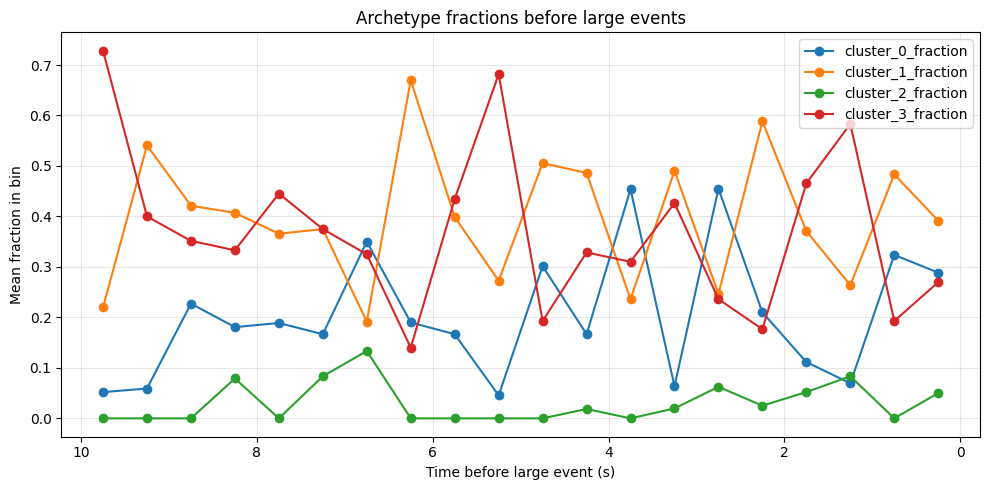

In [15]:
cluster_cols = [c for c in cluster_precursor_df.columns if c.startswith('cluster_')]
plt.figure(figsize=(10,5))
for col in cluster_cols:
    plt.plot(cluster_precursor_df['time_before_s'], cluster_precursor_df[col], marker='o', label=col)
plt.gca().invert_xaxis()
plt.xlabel('Time before large event (s)')
plt.ylabel('Mean fraction in bin')
plt.title('Archetype fractions before large events')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 10) What to look for

Promising precursor evidence would include any of the following patterns:

- **event rate rises** as time approaches a large event,
- **mean or median AE energy rises** before large events,
- **spectral centroid / entropy drift** in a consistent direction,
- **inter-event times shorten** before major avalanches,
- **archetype fractions shift** systematically before large events.

If one or more of those appear stable under different large-event thresholds and window lengths, the next natural step is to formalize them into a simple predictive benchmark.
